In [2]:
!pip install -q ultralytics split-folders opencv-python matplotlib seaborn pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.0 MB/s eta 0:00:00


In [3]:
import os
import zipfile
import random
import shutil

import cv2
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

print("Libraries imported successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Libraries imported successfully.


In [5]:
from google.colab import files

uploaded = files.upload()

Saving Project5_Ag_Crop and weed detection.zip to Project5_Ag_Crop and weed detection.zip


In [6]:
import zipfile

zip_path = "Project5_Ag_Crop and weed detection.zip"
extract_path = "cropweed"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [7]:
import os

for root, dirs, files in os.walk("cropweed"):
    print(root)
    print("Folders:", dirs)
    print("Files:", files[:5])
    print("-" * 60)

cropweed
Folders: ['agri_data']
Files: ['classes.txt']
------------------------------------------------------------
cropweed/agri_data
Folders: ['data']
Files: []
------------------------------------------------------------
cropweed/agri_data/data
Folders: []
Files: ['agri_0_2521.txt', 'agri_0_1908.jpeg', 'agri_0_9489.jpeg', 'agri_0_3856.jpeg', 'agri_0_5260.txt']
------------------------------------------------------------


In [8]:
import os
import shutil
import random

random.seed(42)

source_dir = "cropweed/agri_data/data"

base_dir = "dataset"

train_img = os.path.join(base_dir, "train/images")
train_lbl = os.path.join(base_dir, "train/labels")

val_img = os.path.join(base_dir, "valid/images")
val_lbl = os.path.join(base_dir, "valid/labels")

test_img = os.path.join(base_dir, "test/images")
test_lbl = os.path.join(base_dir, "test/labels")

for folder in [train_img, train_lbl, val_img, val_lbl, test_img, test_lbl]:
    os.makedirs(folder, exist_ok=True)

images = sorted([
    f for f in os.listdir(source_dir)
    if f.endswith(".jpeg") or f.endswith(".jpg") or f.endswith(".png")
])

random.shuffle(images)

n = len(images)

train_end = int(0.70 * n)
val_end = int(0.85 * n)

train_images = images[:train_end]
val_images = images[train_end:val_end]
test_images = images[val_end:]

def copy_files(image_list, img_dest, lbl_dest):
    for img in image_list:
        label = os.path.splitext(img)[0] + ".txt"

        shutil.copy(
            os.path.join(source_dir, img),
            os.path.join(img_dest, img)
        )

        shutil.copy(
            os.path.join(source_dir, label),
            os.path.join(lbl_dest, label)
        )

copy_files(train_images, train_img, train_lbl)
copy_files(val_images, val_img, val_lbl)
copy_files(test_images, test_img, test_lbl)

print("Dataset prepared successfully!")

print(f"Training Images : {len(train_images)}")
print(f"Validation Images : {len(val_images)}")
print(f"Testing Images : {len(test_images)}")

Dataset prepared successfully!
Training Images : 909
Validation Images : 196
Testing Images : 195


In [9]:
print("Train Images :", len(os.listdir(train_img)))
print("Train Labels :", len(os.listdir(train_lbl)))

print("Validation Images :", len(os.listdir(val_img)))
print("Validation Labels :", len(os.listdir(val_lbl)))

print("Test Images :", len(os.listdir(test_img)))
print("Test Labels :", len(os.listdir(test_lbl)))

Train Images : 909
Train Labels : 909
Validation Images : 196
Validation Labels : 196
Test Images : 195
Test Labels : 195


In [10]:
data = {
    "path": "/content/dataset",
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",

    "nc": 2,

    "names": [
        "crop",
        "weed"
    ]
}

with open("data.yaml","w") as f:
    yaml.dump(data,f)

print("data.yaml created successfully!")

data.yaml created successfully!


In [11]:
with open("data.yaml") as f:
    print(f.read())

names:
- crop
- weed
nc: 2
path: /content/dataset
test: test/images
train: train/images
val: valid/images



In [12]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

print("YOLOv8 model loaded successfully!")

YOLOv8 model loaded successfully!


In [13]:
results = model.train(

    data="data.yaml",

    epochs=30,

    imgsz=512,

    batch=16,

    patience=10,

    workers=2,

    device=0,

    project="Crop_Weed_Project",

    name="YOLOv8",

    pretrained=True,

    optimizer="Adam",

    verbose=True

)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=True, patience=10, 

In [14]:
metrics = model.val()

print(metrics)

Ultralytics 8.4.103 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1752.4±300.5 MB/s, size: 65.1 KB)
val: Scanning /content/dataset/valid/labels.cache... 196 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 196/196 51.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 4.2it/s 3.1s
                   all        196        283      0.863      0.774      0.865      0.555
                  crop        101        158      0.873       0.78      0.875       0.63
                  weed         97        125      0.853      0.768      0.854      0.479
Speed: 2.9ms preprocess, 4.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultra

In [15]:
import random
import os

test_folder = "dataset/test/images"

image = random.choice(os.listdir(test_folder))

image_path = os.path.join(test_folder, image)

results = model.predict(

    source=image_path,

    save=True,

    conf=0.25

)

print(image)


image 1/1 /content/dataset/test/images/agri_0_6292.jpeg: 512x512 1 weed, 8.3ms
Speed: 1.5ms preprocess, 8.3ms inference, 2.0ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/runs/detect/predict
agri_0_6292.jpeg


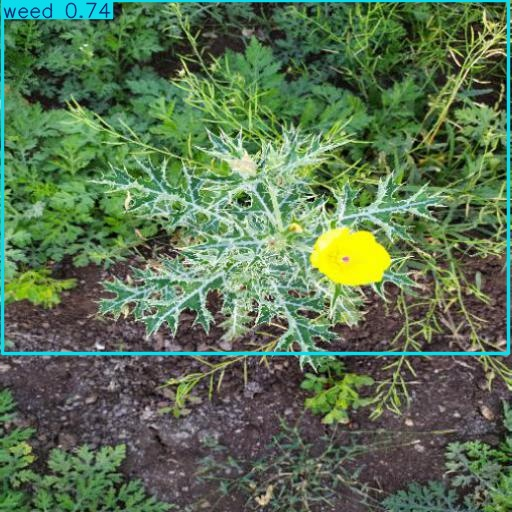

In [16]:
from IPython.display import Image

prediction_folder = "runs/detect/predict"

prediction_image = os.listdir(prediction_folder)[0]

Image(os.path.join(prediction_folder, prediction_image))

In [18]:
import shutil

source = "runs/detect/Crop_Weed_Project/YOLOv8/weights/best.pt"
destination = "best_cropweed_model.pt"

shutil.copy(source, destination)
print("Model saved successfully!")

Model saved successfully!
